In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=250

In [4]:
# 1. DATA LOADING & INSPECTION
# ======================
df = pd.read_excel("Agri_Maha_Final.xlsx")

# Initial inspection

print("\nFirst 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())



First 5 Rows:
     District   Crop     Year  Season  Area(Ha)  Production(tons)  \
0  AURANGABAD  Bajra  2010-11  Kharif     89800            126500   
1        BEED  Bajra  2010-11  Kharif    122500            112800   
2       DHULE  Bajra  2010-11  Kharif    109400            171300   
3     JALGAON  Bajra  2010-11  Kharif     35800             49800   
4      NASHIK  Bajra  2010-11  Kharif    171200            216300   

   Yield(ton/ha)  
0           1.41  
1           0.92  
2           1.57  
3           1.39  
4           1.26  

Last 5 Rows:
      District   Crop     Year  Season  Area(Ha)  Production(tons)  \
1297  BULDHANA   Urad  2019-20  Kharif     16580             11031   
1298  KOLHAPUR   Urad  2019-20  Kharif      1871              1564   
1299     LATUR   Urad  2019-20  Kharif      7538              4287   
1300    GONDIA  Wheat  2019-20    Rabi      3032              1690   
1301  KOLHAPUR  Wheat  2019-20    Rabi      3398              8001   

      Yield(ton/ha)  

In [5]:
print("\nData Types:")
print(df.dtypes)
print("\n================================")
print("\nDataset Shape:\n")
print(df.shape)
print("\n================================")
print("\nMissing Values:\n")
print(df.isnull().sum())


Data Types:
District             object
Crop                 object
Year                 object
Season               object
Area(Ha)              int64
Production(tons)      int64
Yield(ton/ha)       float64
dtype: object


Dataset Shape:

(1302, 7)


Missing Values:

District            0
Crop                0
Year                0
Season              0
Area(Ha)            0
Production(tons)    0
Yield(ton/ha)       0
dtype: int64


In [6]:
# ======================
# 2. DATA CLEANING
# ======================

In [7]:
data_kharif = df[df['Season'] == 'Kharif'].sort_values(by='Year')
data_rabi = df[df['Season'] == 'Rabi'].sort_values(by='Year')
data_wyear = df[df['Season'] == 'Whole Year'].sort_values(by='Year')

In [8]:
data_kharif.head()

,District,Crop,Year,Season,Area(Ha),Production(tons),Yield(ton/ha)
0,AURANGABAD,Bajra,2010-11,Kharif,89800,126500,1.41
191,NAGPUR,Castor seed,2010-11,Kharif,100,100,1.00
190,KOLHAPUR,Castor seed,2010-11,Kharif,200,100,0.50
189,HINGOLI,Castor seed,2010-11,Kharif,400,100,0.25
188,CHANDRAPUR,Castor seed,2010-11,Kharif,100,100,1.00


In [9]:
data_rabi.head()

,District,Crop,Year,Season,Area(Ha),Production(tons),Yield(ton/ha)
25,AHMEDNAGAR,Gram,2010-11,Rabi,115200,94000,0.82
177,SANGLI,Wheat,2010-11,Rabi,39300,72900,1.85
176,PUNE,Wheat,2010-11,Rabi,60000,115900,1.93
175,PARBHANI,Wheat,2010-11,Rabi,46400,79500,1.71
174,OSMANABAD,Wheat,2010-11,Rabi,41800,43300,1.04


In [10]:
data_wyear.head()

,District,Crop,Year,Season,Area(Ha),Production(tons),Yield(ton/ha)
137,AHMEDNAGAR,Sugarcane,2010-11,Whole Year,126000,11516400,91.4
156,YAVATMAL,Sugarcane,2010-11,Whole Year,4500,300600,66.8
155,WARDHA,Sugarcane,2010-11,Whole Year,2000,136800,68.4
154,SOLAPUR,Sugarcane,2010-11,Whole Year,163100,16000100,98.1
153,SATARA,Sugarcane,2010-11,Whole Year,74000,6963400,94.1


In [11]:
print(f"Total Whole-Year Records : {data_wyear.shape}")
print(f"Total Kharif Records : {data_kharif.shape}")
print(f"Total Rabi Records : {data_rabi.shape}")

Total Whole-Year Records : (78, 7)
Total Kharif Records : (741, 7)
Total Rabi Records : (483, 7)


In [12]:
print(data_kharif.describe())

            Area(Ha)  Production(tons)  Yield(ton/ha)
count     741.000000      7.410000e+02     741.000000
mean    51223.156545      7.787870e+04       1.000553
std     85218.180316      1.463412e+05       0.770281
min        66.000000      5.000000e+01       0.100000
25%       300.000000      1.000000e+02       0.350000
50%     12133.000000      8.019000e+03       0.840000
75%     60800.000000      8.840000e+04       1.460000
max    558800.000000      1.097100e+06       4.000000


In [13]:
print(data_rabi.describe())

            Area(Ha)  Production(tons)  Yield(ton/ha)
count     483.000000        483.000000     483.000000
mean    39497.763975      38091.467909       0.987143
std     87751.273217      66565.510479       0.757623
min        50.000000         50.000000       0.110000
25%       200.000000        100.000000       0.500000
50%      5600.000000      11600.000000       0.840000
75%     41750.000000      55200.000000       1.255000
max    765000.000000     593200.000000       7.890000


In [14]:
print(data_wyear.describe())

            Area(Ha)  Production(tons)  Yield(ton/ha)
count      78.000000      7.800000e+01      78.000000
mean    38534.794872      3.263733e+06      73.903333
std     48168.198691      4.476390e+06      16.519335
min        64.000000      3.840000e+03      34.530000
25%      4275.000000      3.013500e+05      65.917500
50%     15150.000000      1.107050e+06      71.825000
75%     57725.000000      3.619200e+06      84.767500
max    173400.000000      1.600010e+07     116.410000


In [15]:
# total records of Crops Based On Season
print(f"Crops In Kharif Season : \n{data_kharif['Crop'].value_counts()}")
print("====================================================")
print(f"Crops In Rabi Season : \n{data_rabi['Crop'].value_counts()}")
print("====================================================")
print(f"Crops In Whole Year Season : {data_wyear['Crop'].value_counts()}")

Crops In Kharif Season : 
Soyabean             81
Cotton(lint)         70
Jowar                62
Sesamum              60
Castor seed          59
Rice                 56
Moong(Green Gram)    53
Urad                 49
Maize                46
Groundnut            41
Bajra                36
Niger seed           30
Arhar/Tur            28
Small millets        26
Sunflower            26
Ragi                 18
Name: Crop, dtype: int64
Crops In Rabi Season : 
Wheat                82
Small millets        67
Gram                 65
Jowar                61
Maize                46
Rapeseed &Mustard    41
Safflower            39
Sunflower            35
Sesamum              26
Linseed              21
Name: Crop, dtype: int64
Crops In Whole Year Season : Sugarcane    78
Name: Crop, dtype: int64


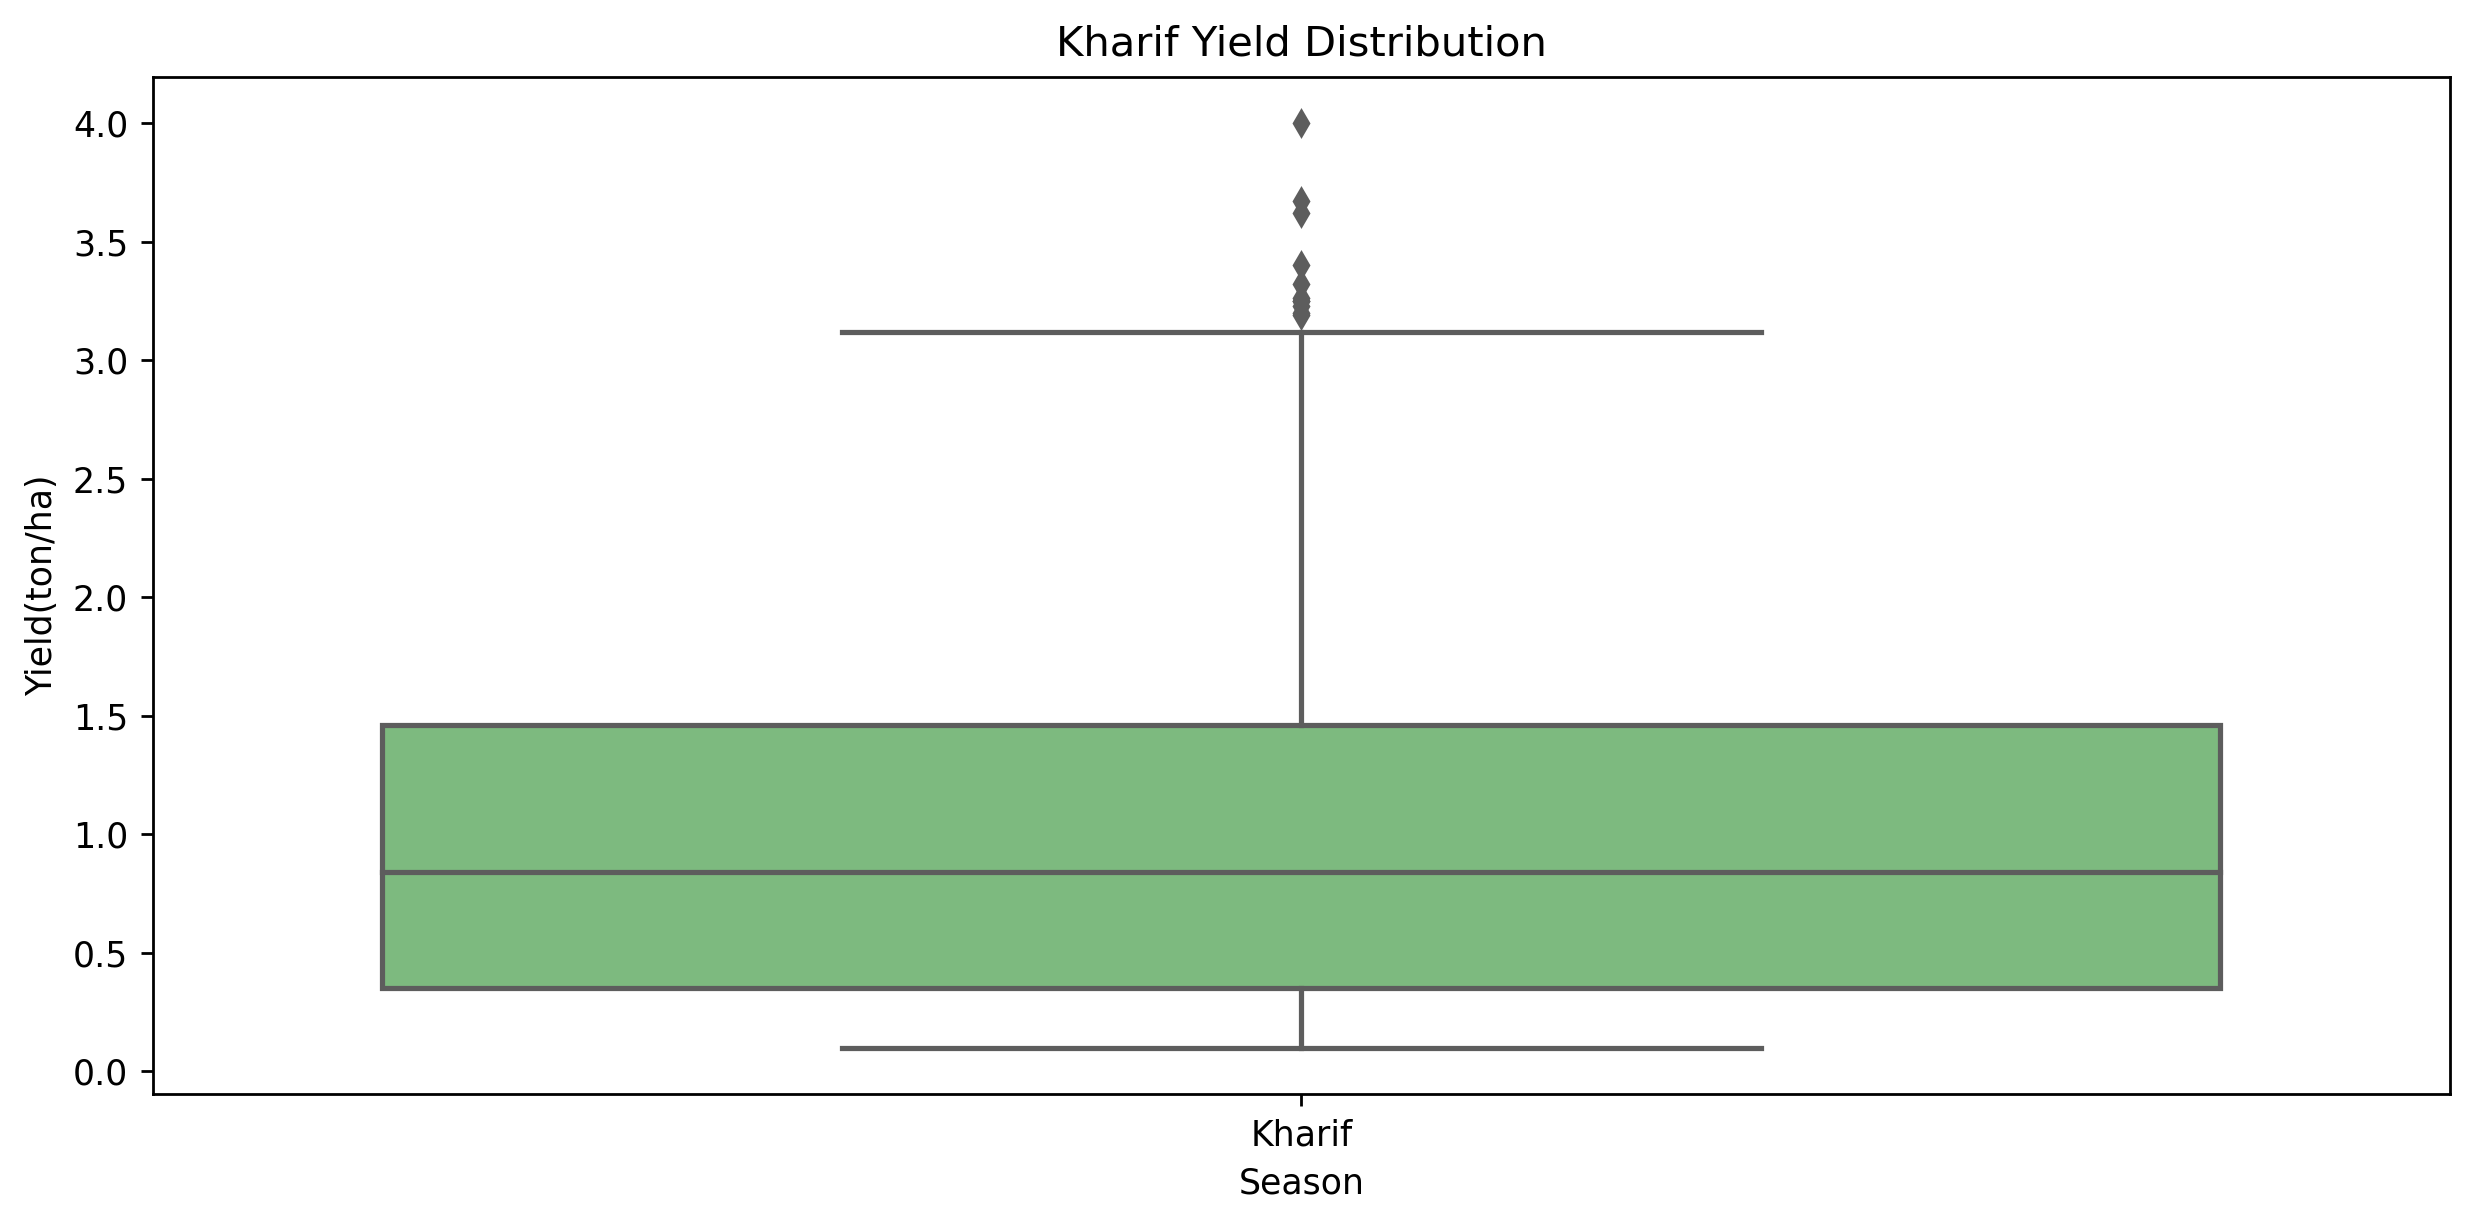

In [16]:
# kharif Box Plot
sns.boxplot(data=data_kharif, x='Season', y='Yield(ton/ha)',palette='Greens')
plt.title('Kharif Yield Distribution')
plt.tight_layout()
plt.show()

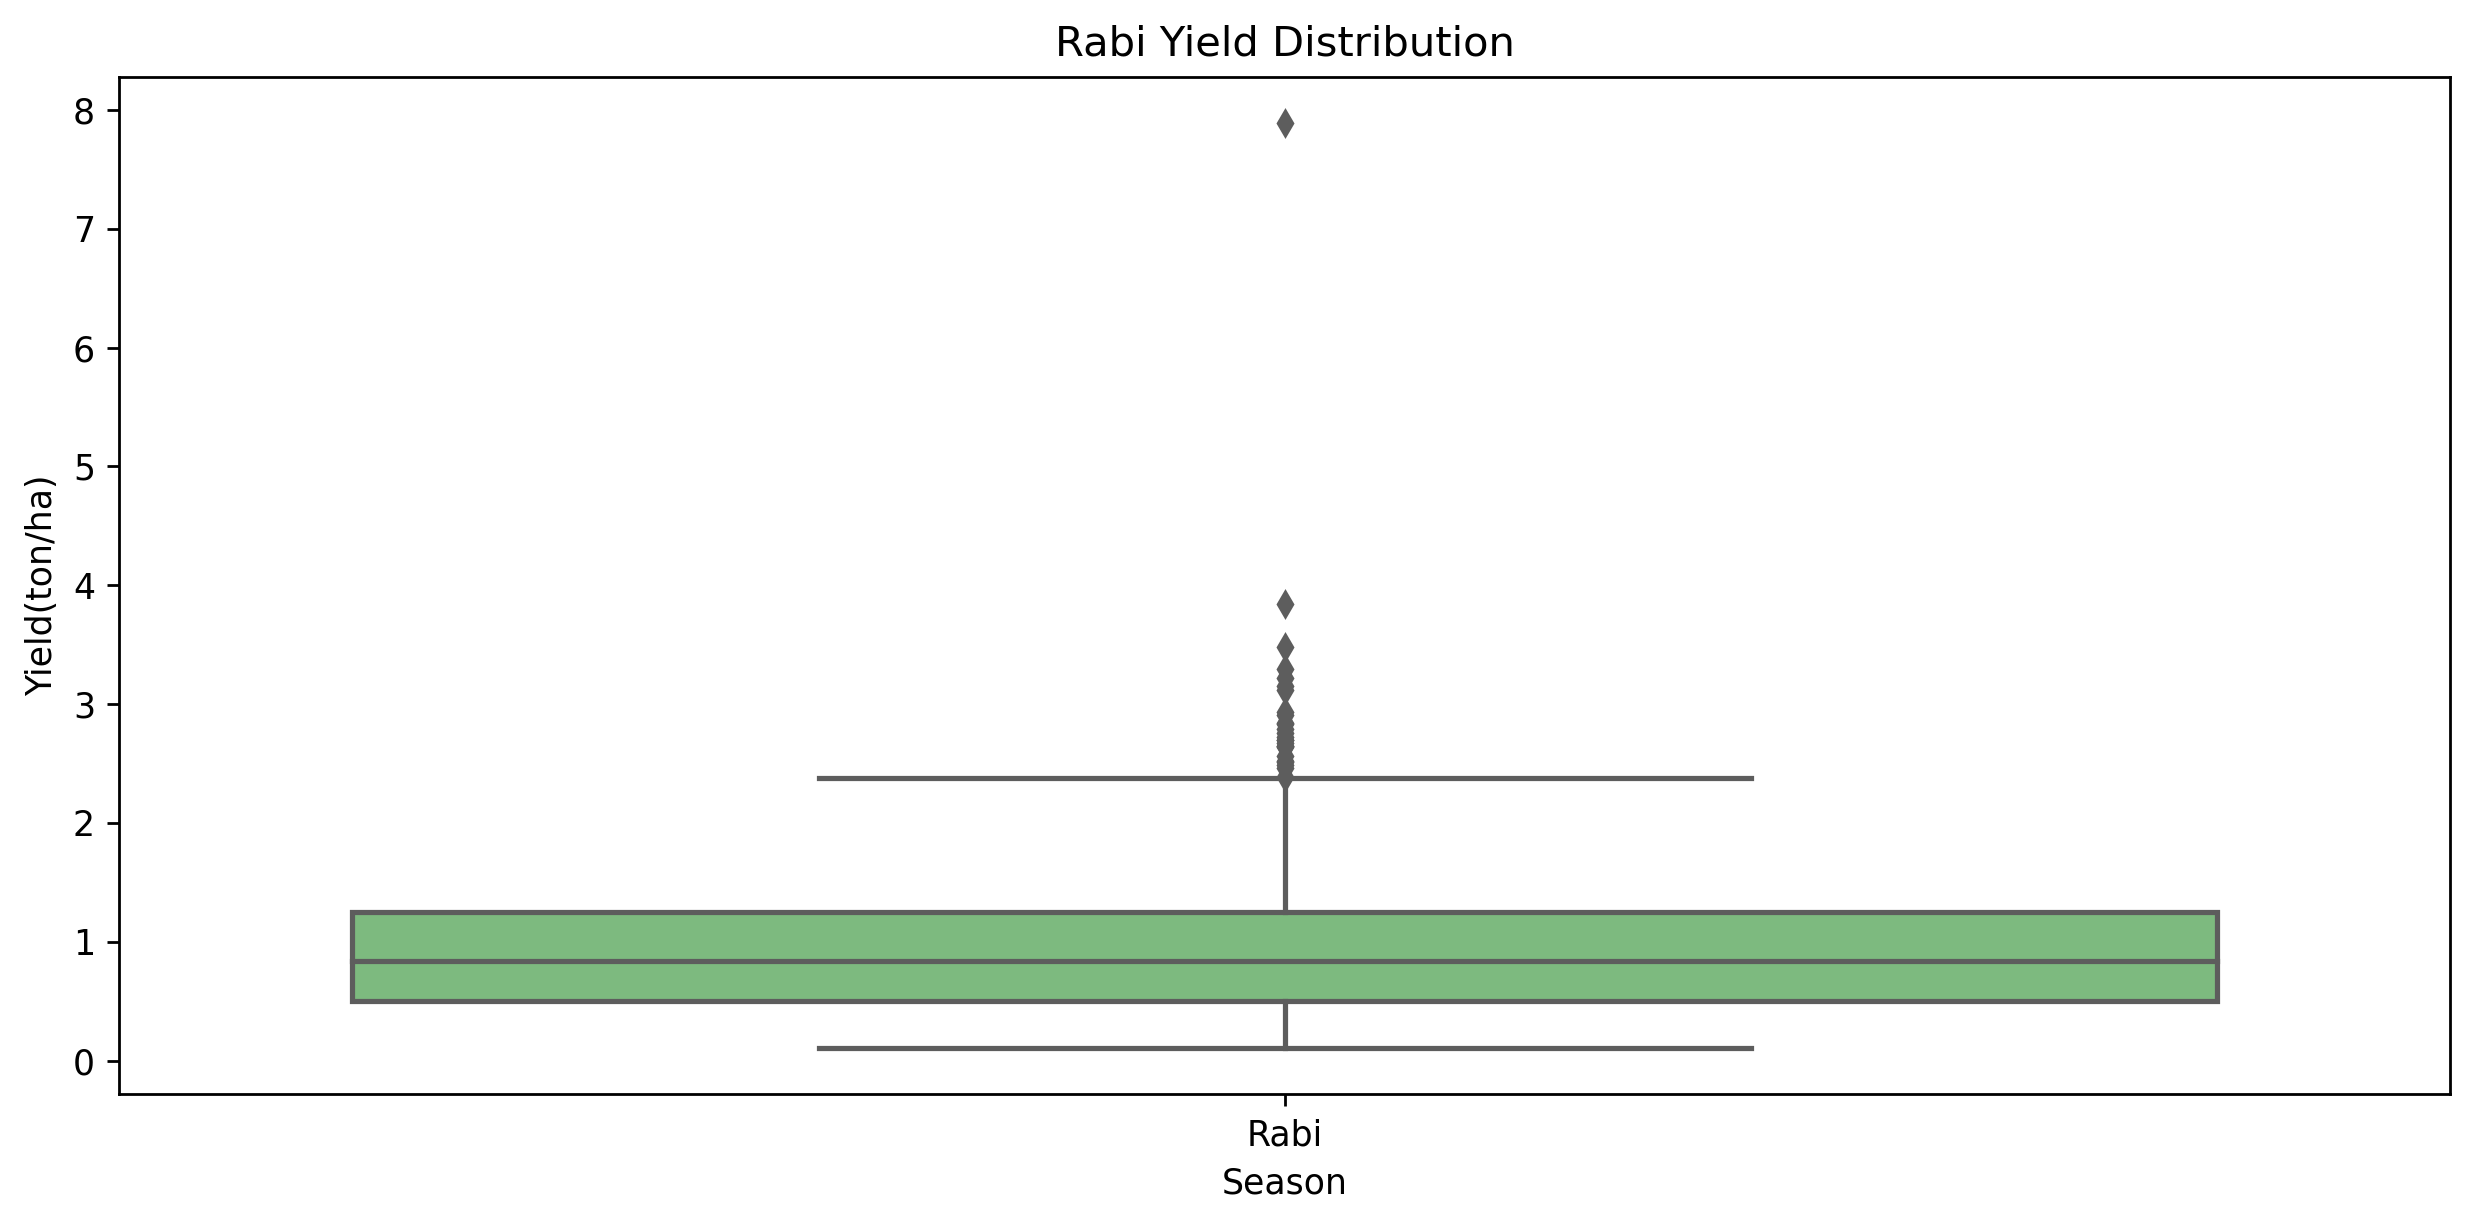

In [17]:
# Rabi Box Plot
sns.boxplot(data=data_rabi, x='Season', y='Yield(ton/ha)',palette='Greens')
plt.title('Rabi Yield Distribution')
plt.tight_layout()
plt.show()

In [18]:
# Handle outliers (for numerical columns)
def handle_outliers(df, columns):
    for col in columns:
        if col in df.select_dtypes(include=np.number).columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

    return lower_bound,upper_bound

In [19]:
kharif_out = handle_outliers(data_kharif,['Yield(ton/ha)'])
rabi_out  = handle_outliers(data_rabi,['Yield(ton/ha)'])
wyear_out = handle_outliers(data_wyear,['Yield(ton/ha)'])
print("Kharif Upper and Lower Limit")
print(f"Lower Bound : {kharif_out[0]}")
print(f"Upper Bound : {kharif_out[1]}")
print("====================================================")
print("Rabi Upper and Lower Limit")
print(f"Lower Bound : {rabi_out[0]}")
print(f"Upper Bound : {rabi_out[1]}")
print("====================================================")
print("Whole Year Upper and Lower Limit")
print(f"Lower Bound : {wyear_out[0]}")
print(f"Upper Bound : {wyear_out[1]}")

Kharif Upper and Lower Limit
Lower Bound : -1.315
Upper Bound : 3.125
Rabi Upper and Lower Limit
Lower Bound : -0.6324999999999998
Upper Bound : 2.3874999999999997
Whole Year Upper and Lower Limit
Lower Bound : 37.64250000000001
Upper Bound : 113.04249999999999


In [20]:
# Count outliers
# Total Whole-Year Records : 79
# Total Kharif     Records : 1100
# Total Rabi       Records : 745
kharif_outliers = data_kharif[(data_kharif['Yield(ton/ha)'] < kharif_out[0]) | (data_kharif['Yield(ton/ha)'] > kharif_out[1])]
rabi_outliers = data_rabi[(data_rabi['Yield(ton/ha)'] < rabi_out[0]) | (data_rabi['Yield(ton/ha)'] > rabi_out[1])]
wyear_outliers = data_wyear[(data_wyear['Yield(ton/ha)'] < wyear_out[0]) | (data_wyear['Yield(ton/ha)'] > wyear_out[1])]

print(f"Total outliers in Kharif dataset: {len(kharif_outliers)}")
print(f"Total outliers in Rabi dataset: {len(rabi_outliers)}")
print(f"Total outliers in Whole Year dataset: {len(wyear_outliers)}")

Total outliers in Kharif dataset: 11
Total outliers in Rabi dataset: 26
Total outliers in Whole Year dataset: 2


# We are going to cap the outliers

In [21]:
# Cap outliers using IQR
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return df

numeric_cols = ["Area(Ha)","Production(tons)", "Yield(ton/ha)"]
filtered_data = cap_outliers(df, numeric_cols)

In [22]:
#========================
# DATA VISUALIZATION
#========================

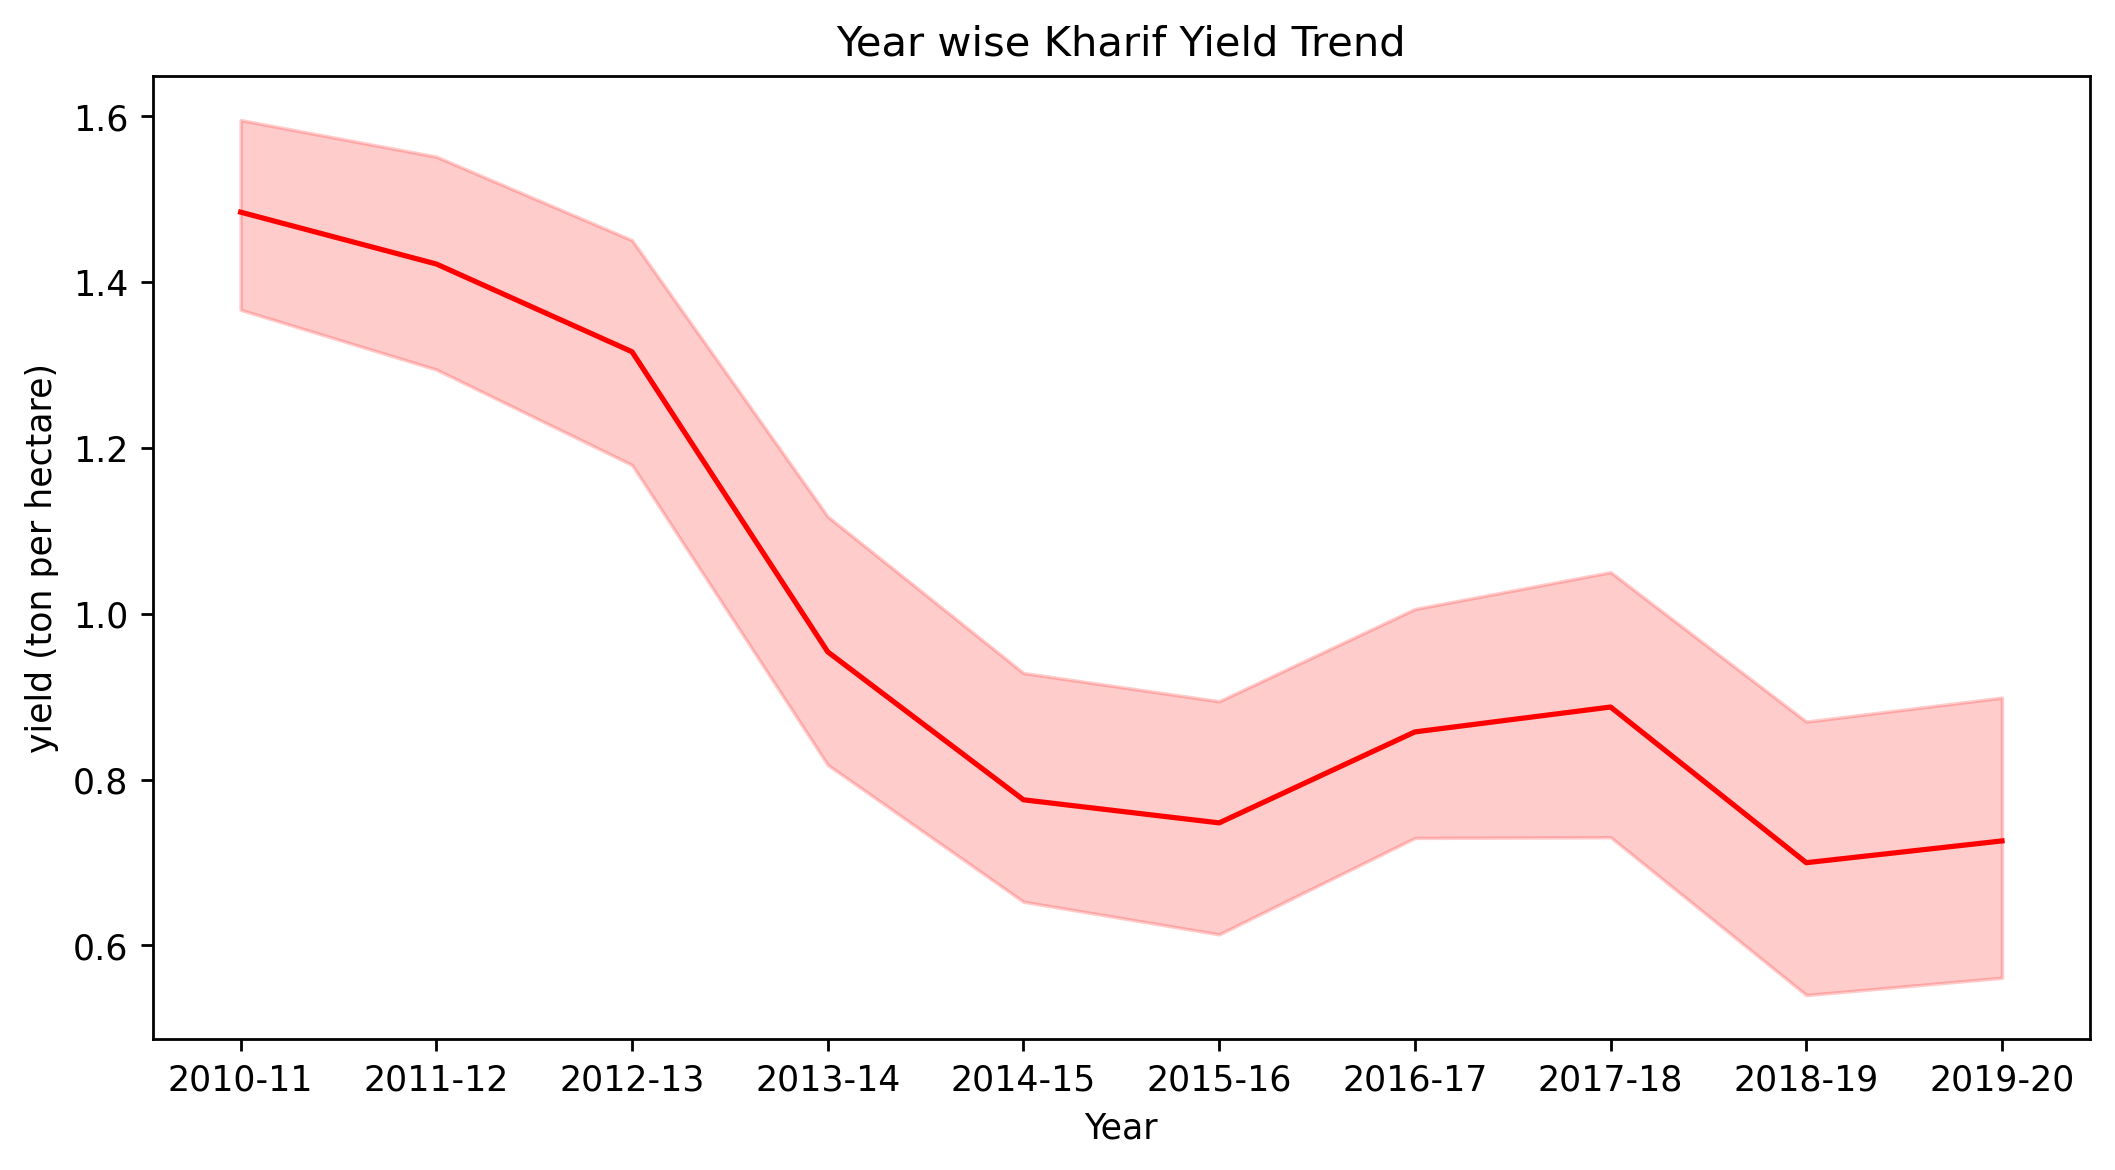

In [23]:
# Kharif Line plot
sns.lineplot(data=filtered_data, x='Year', y='Yield(ton/ha)',color='red')
plt.title('Year wise Kharif Yield Trend')
plt.ylabel("yield (ton per hectare)")
plt.show()

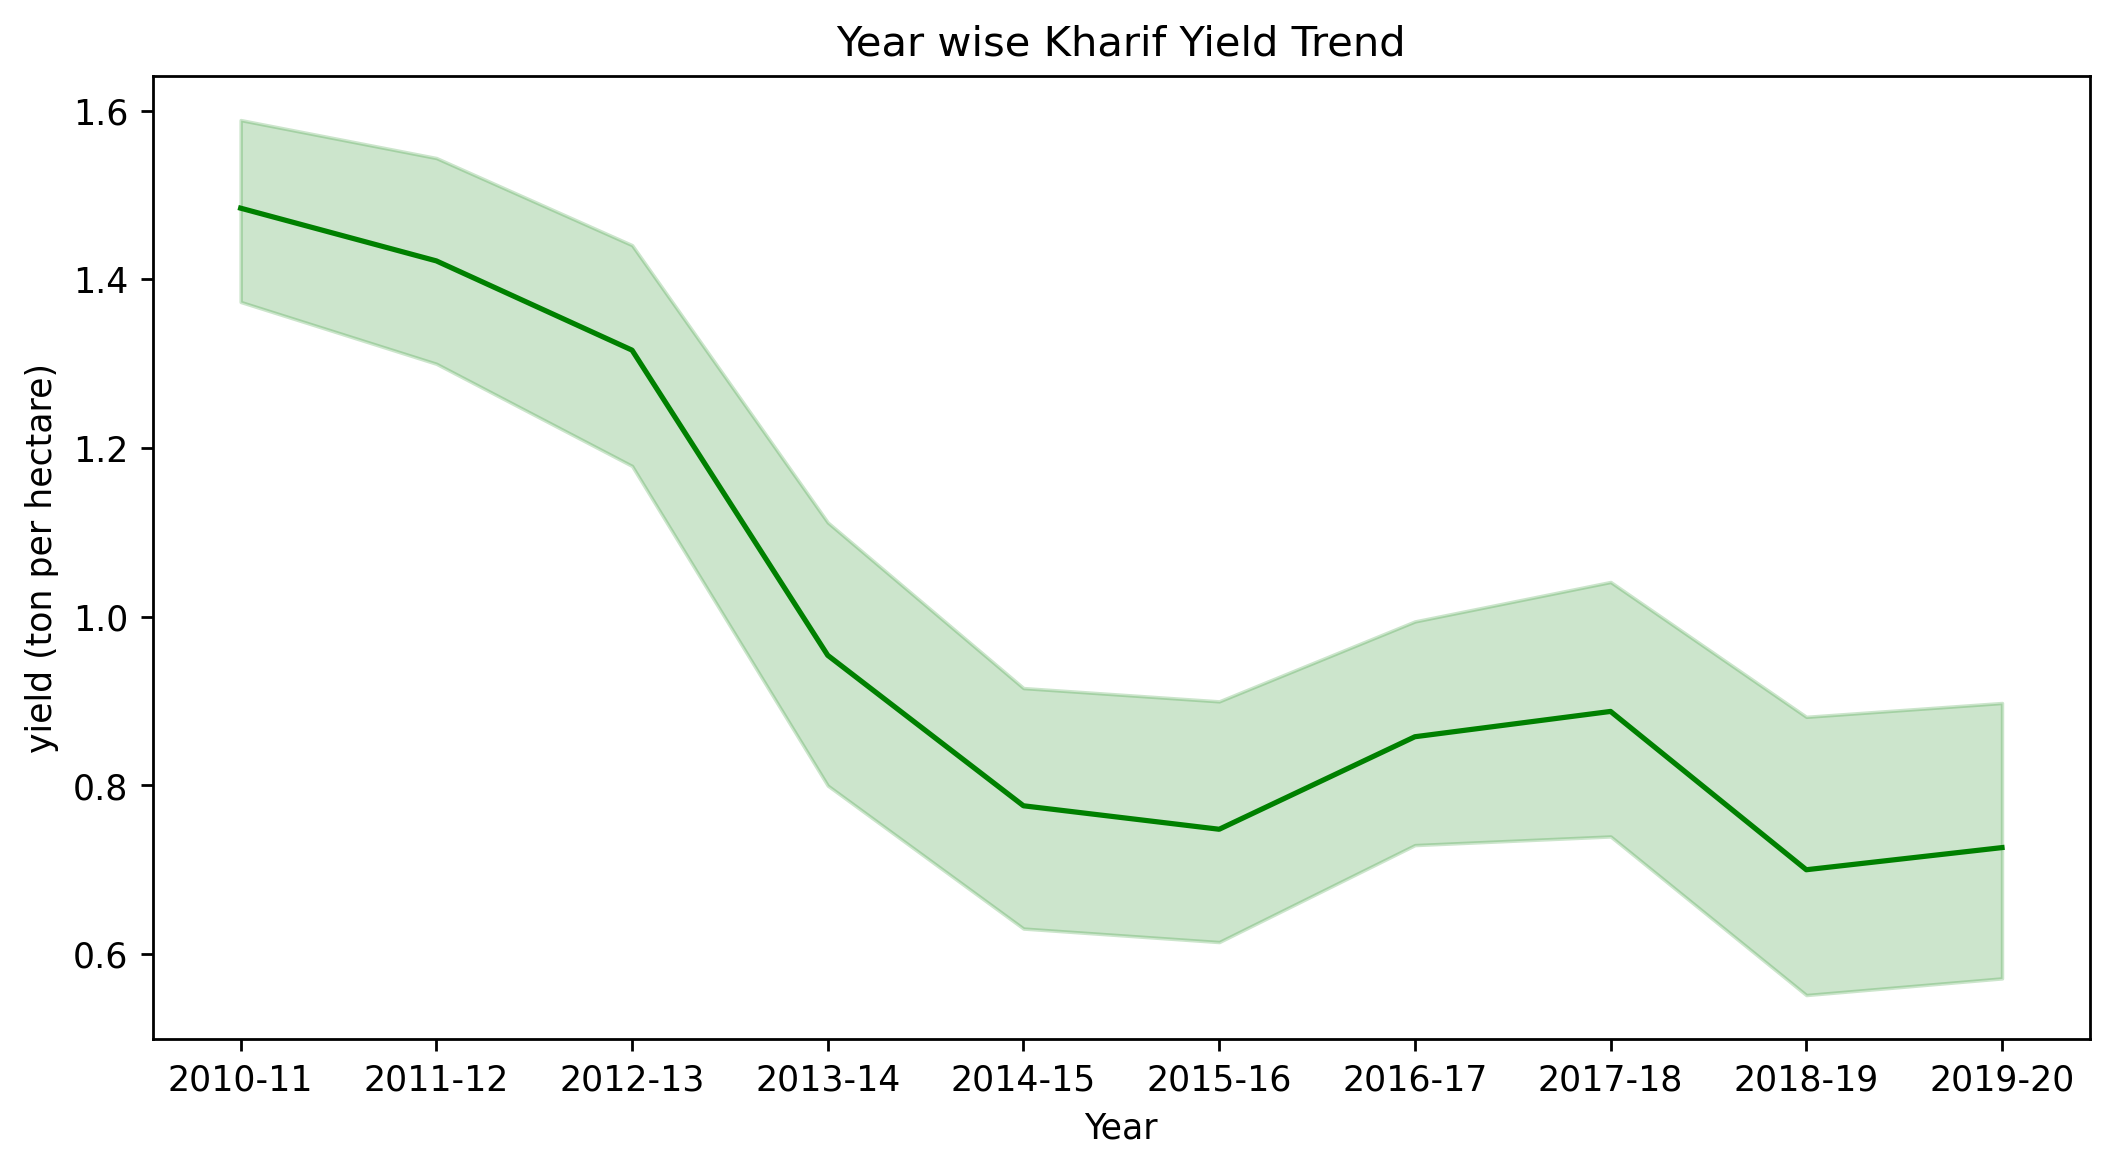

In [24]:
# Rabi Line Plot
sns.lineplot(data=filtered_data, x='Year', y='Yield(ton/ha)',color='green')
plt.title('Year wise Kharif Yield Trend')
plt.ylabel("yield (ton per hectare)")
plt.show()

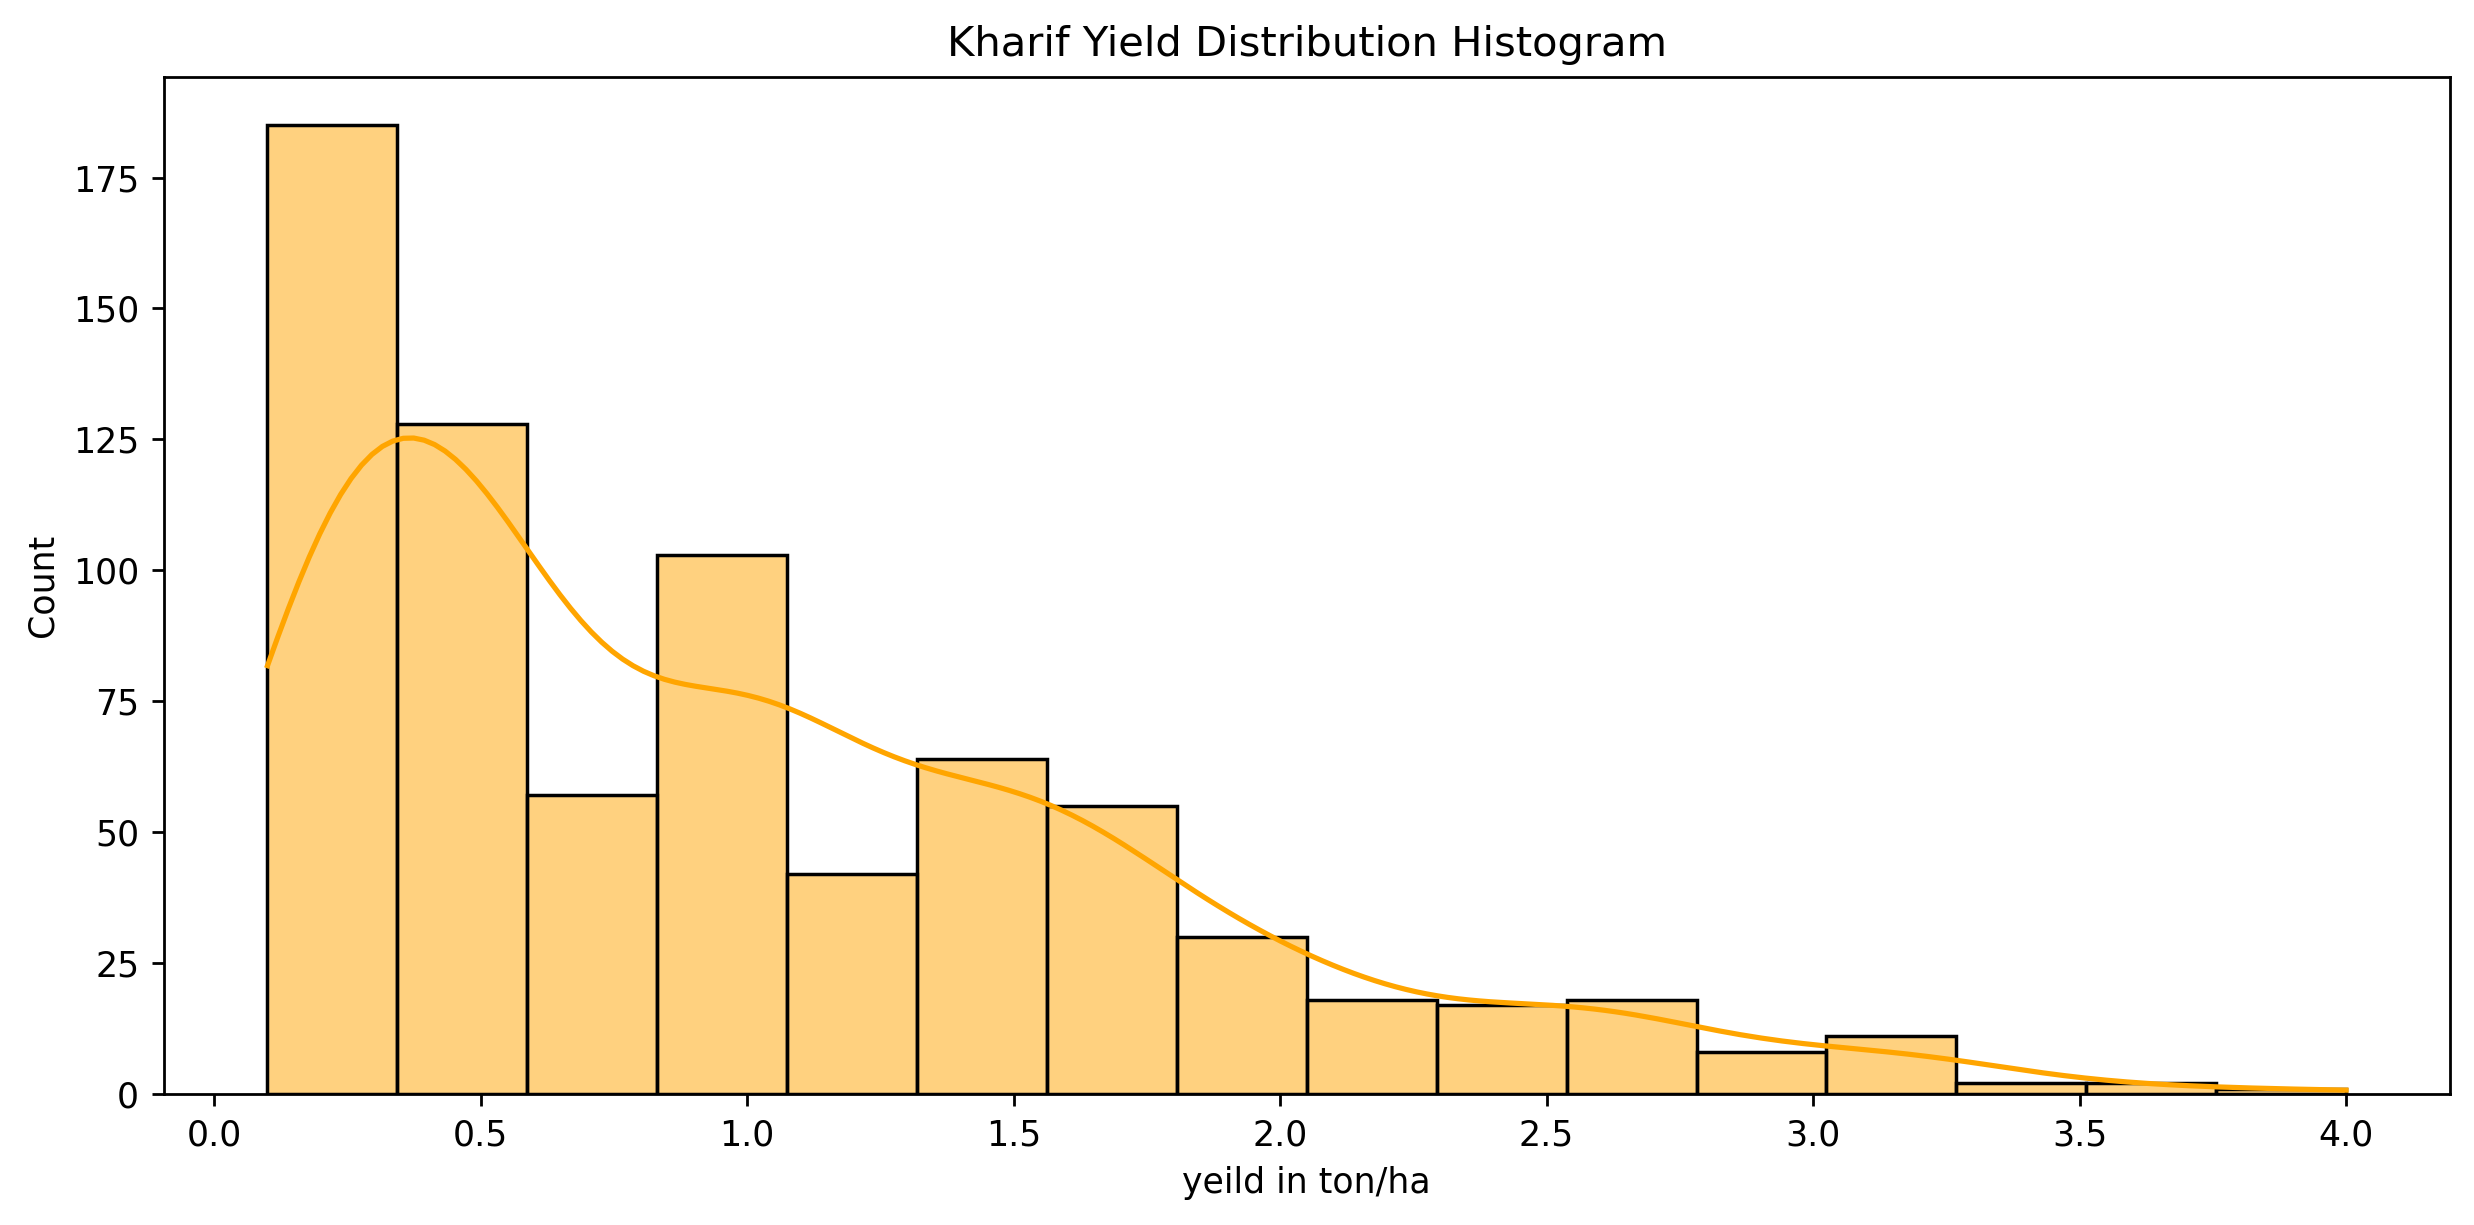

In [25]:
# Kharif Data Distribution
sns.histplot(data_kharif['Yield(ton/ha)'], kde=True, color='orange')
plt.title('Kharif Yield Distribution Histogram')
plt.xlabel("yeild in ton/ha")
plt.tight_layout()
plt.show()

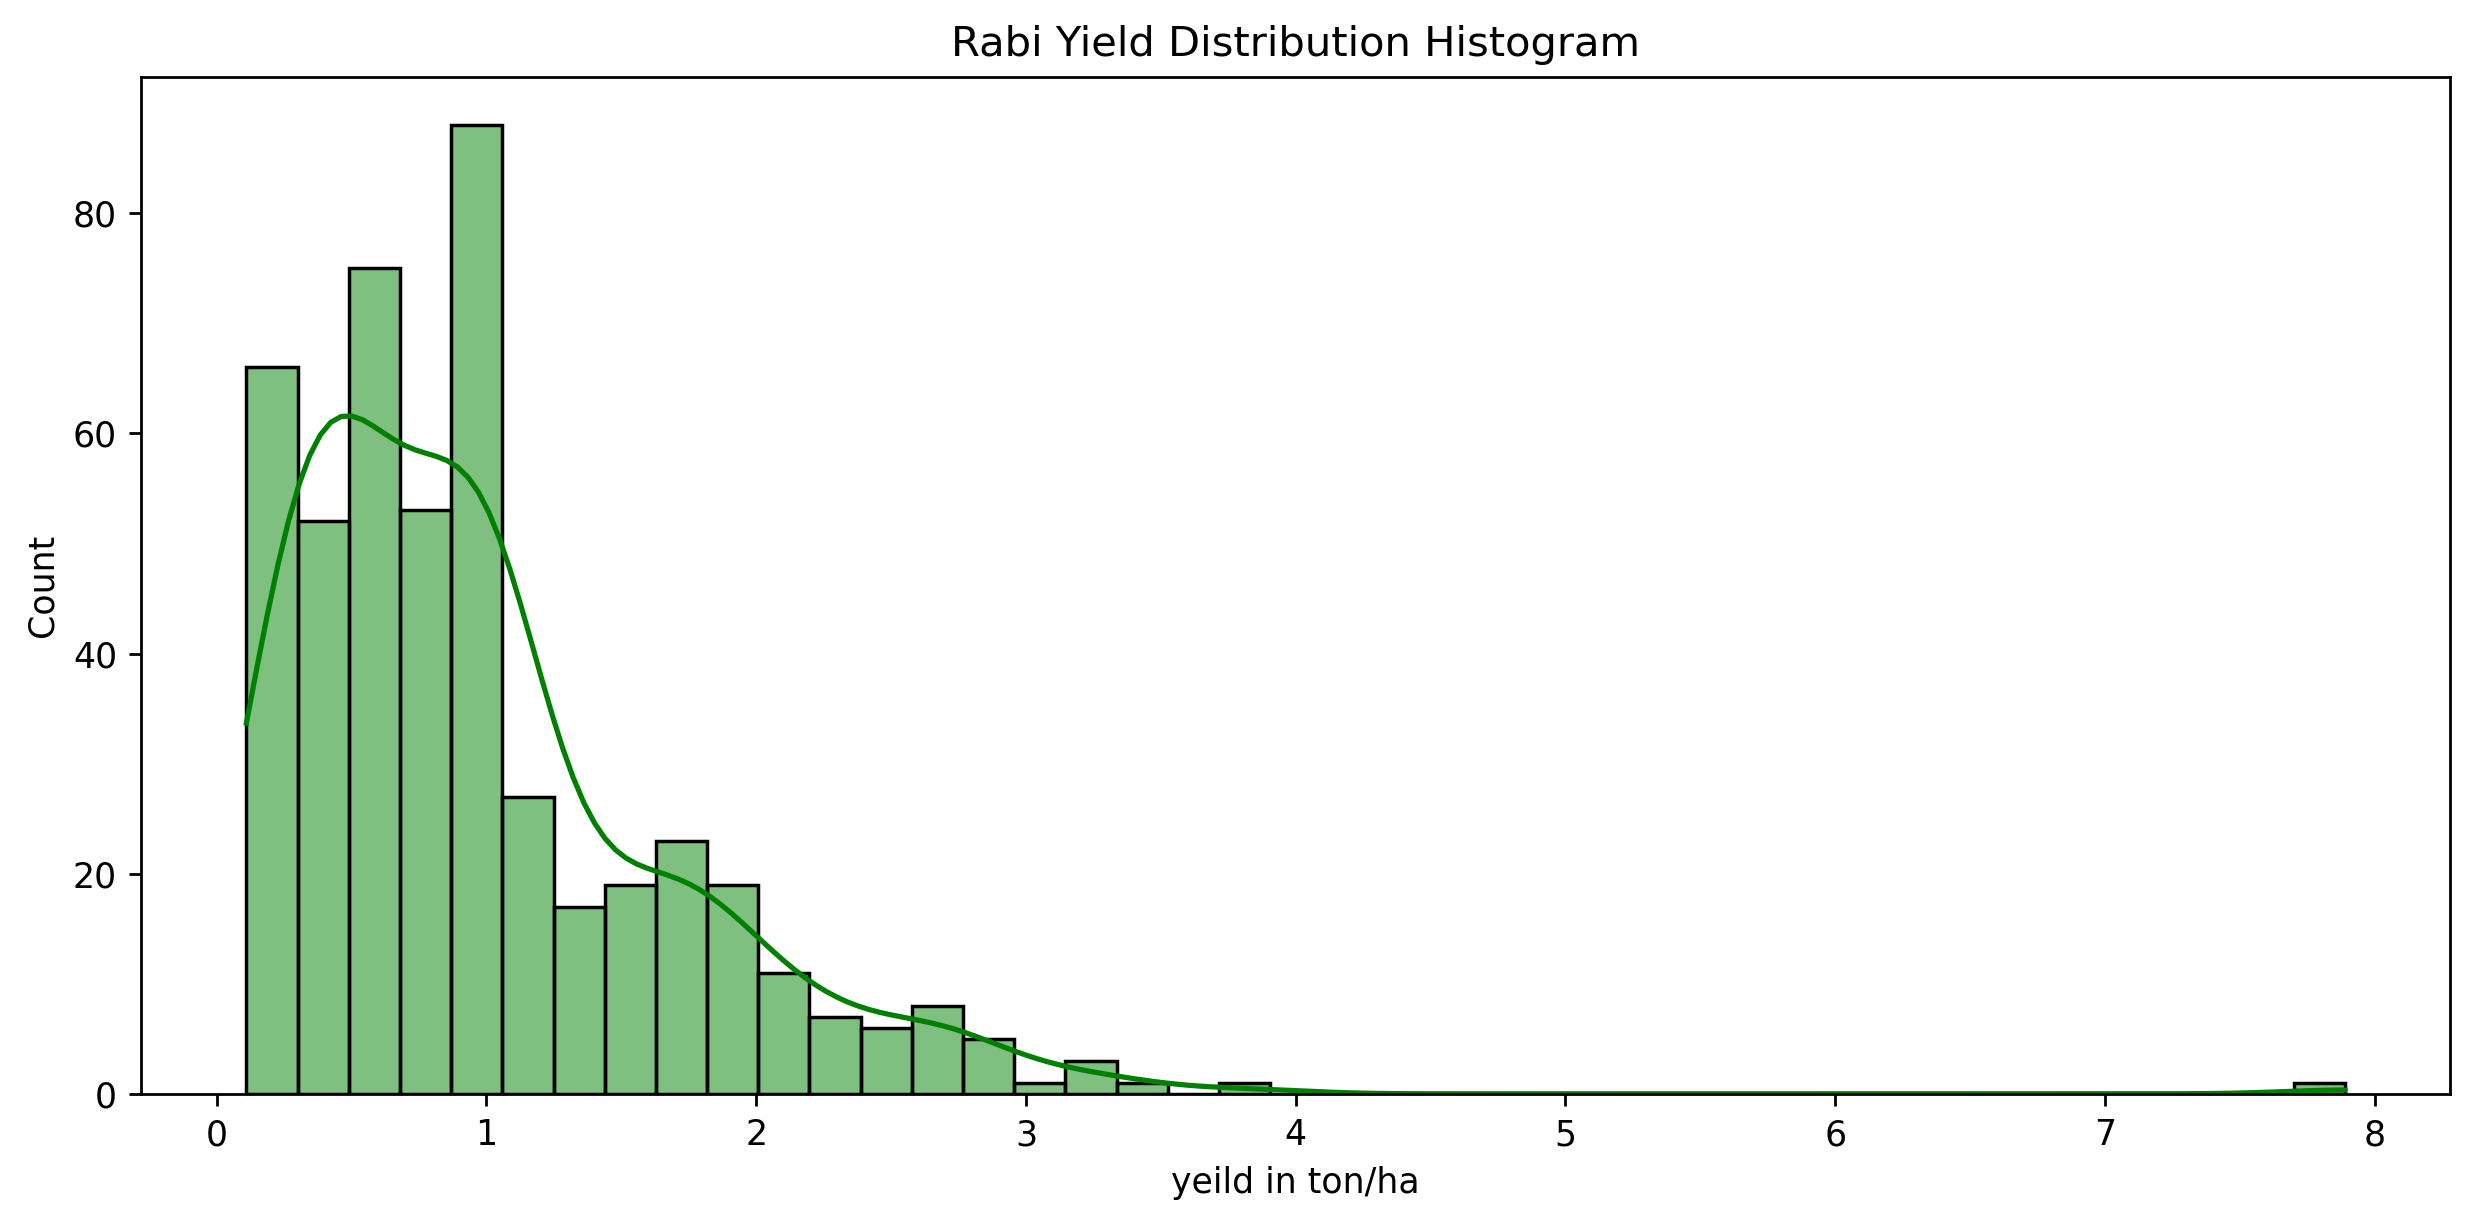

In [26]:
# Rabi Data Distribution
sns.histplot(data_rabi['Yield(ton/ha)'], kde=True, color='green')
plt.title('Rabi Yield Distribution Histogram')
plt.xlabel("yeild in ton/ha")
plt.tight_layout()
plt.show()

In [27]:
# Correlation analysis
corr_matrix = filtered_data.select_dtypes(include=np.number).corr()
print("\nCorrelation Matrix:")
print(corr_matrix)


Correlation Matrix:
                  Area(Ha)  Production(tons)  Yield(ton/ha)
Area(Ha)          1.000000          0.808275       0.309716
Production(tons)  0.808275          1.000000       0.667149
Yield(ton/ha)     0.309716          0.667149       1.000000


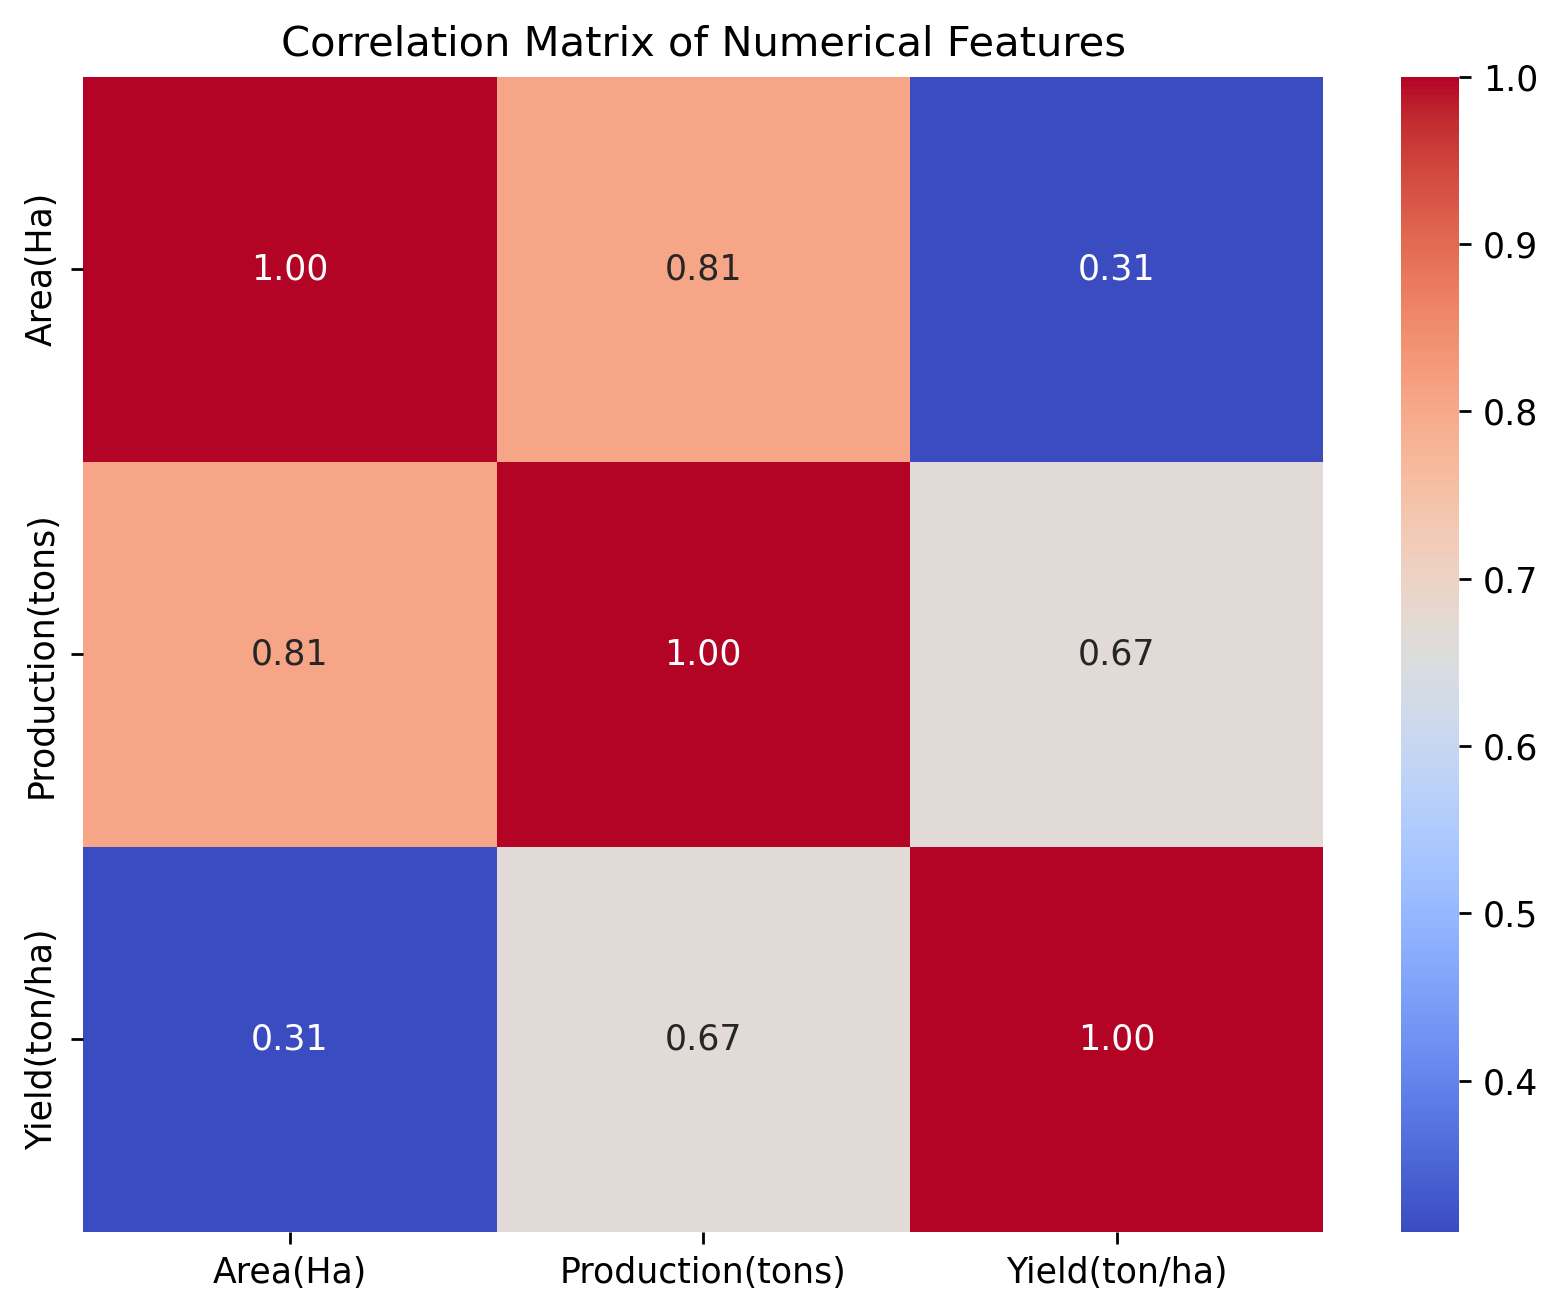

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

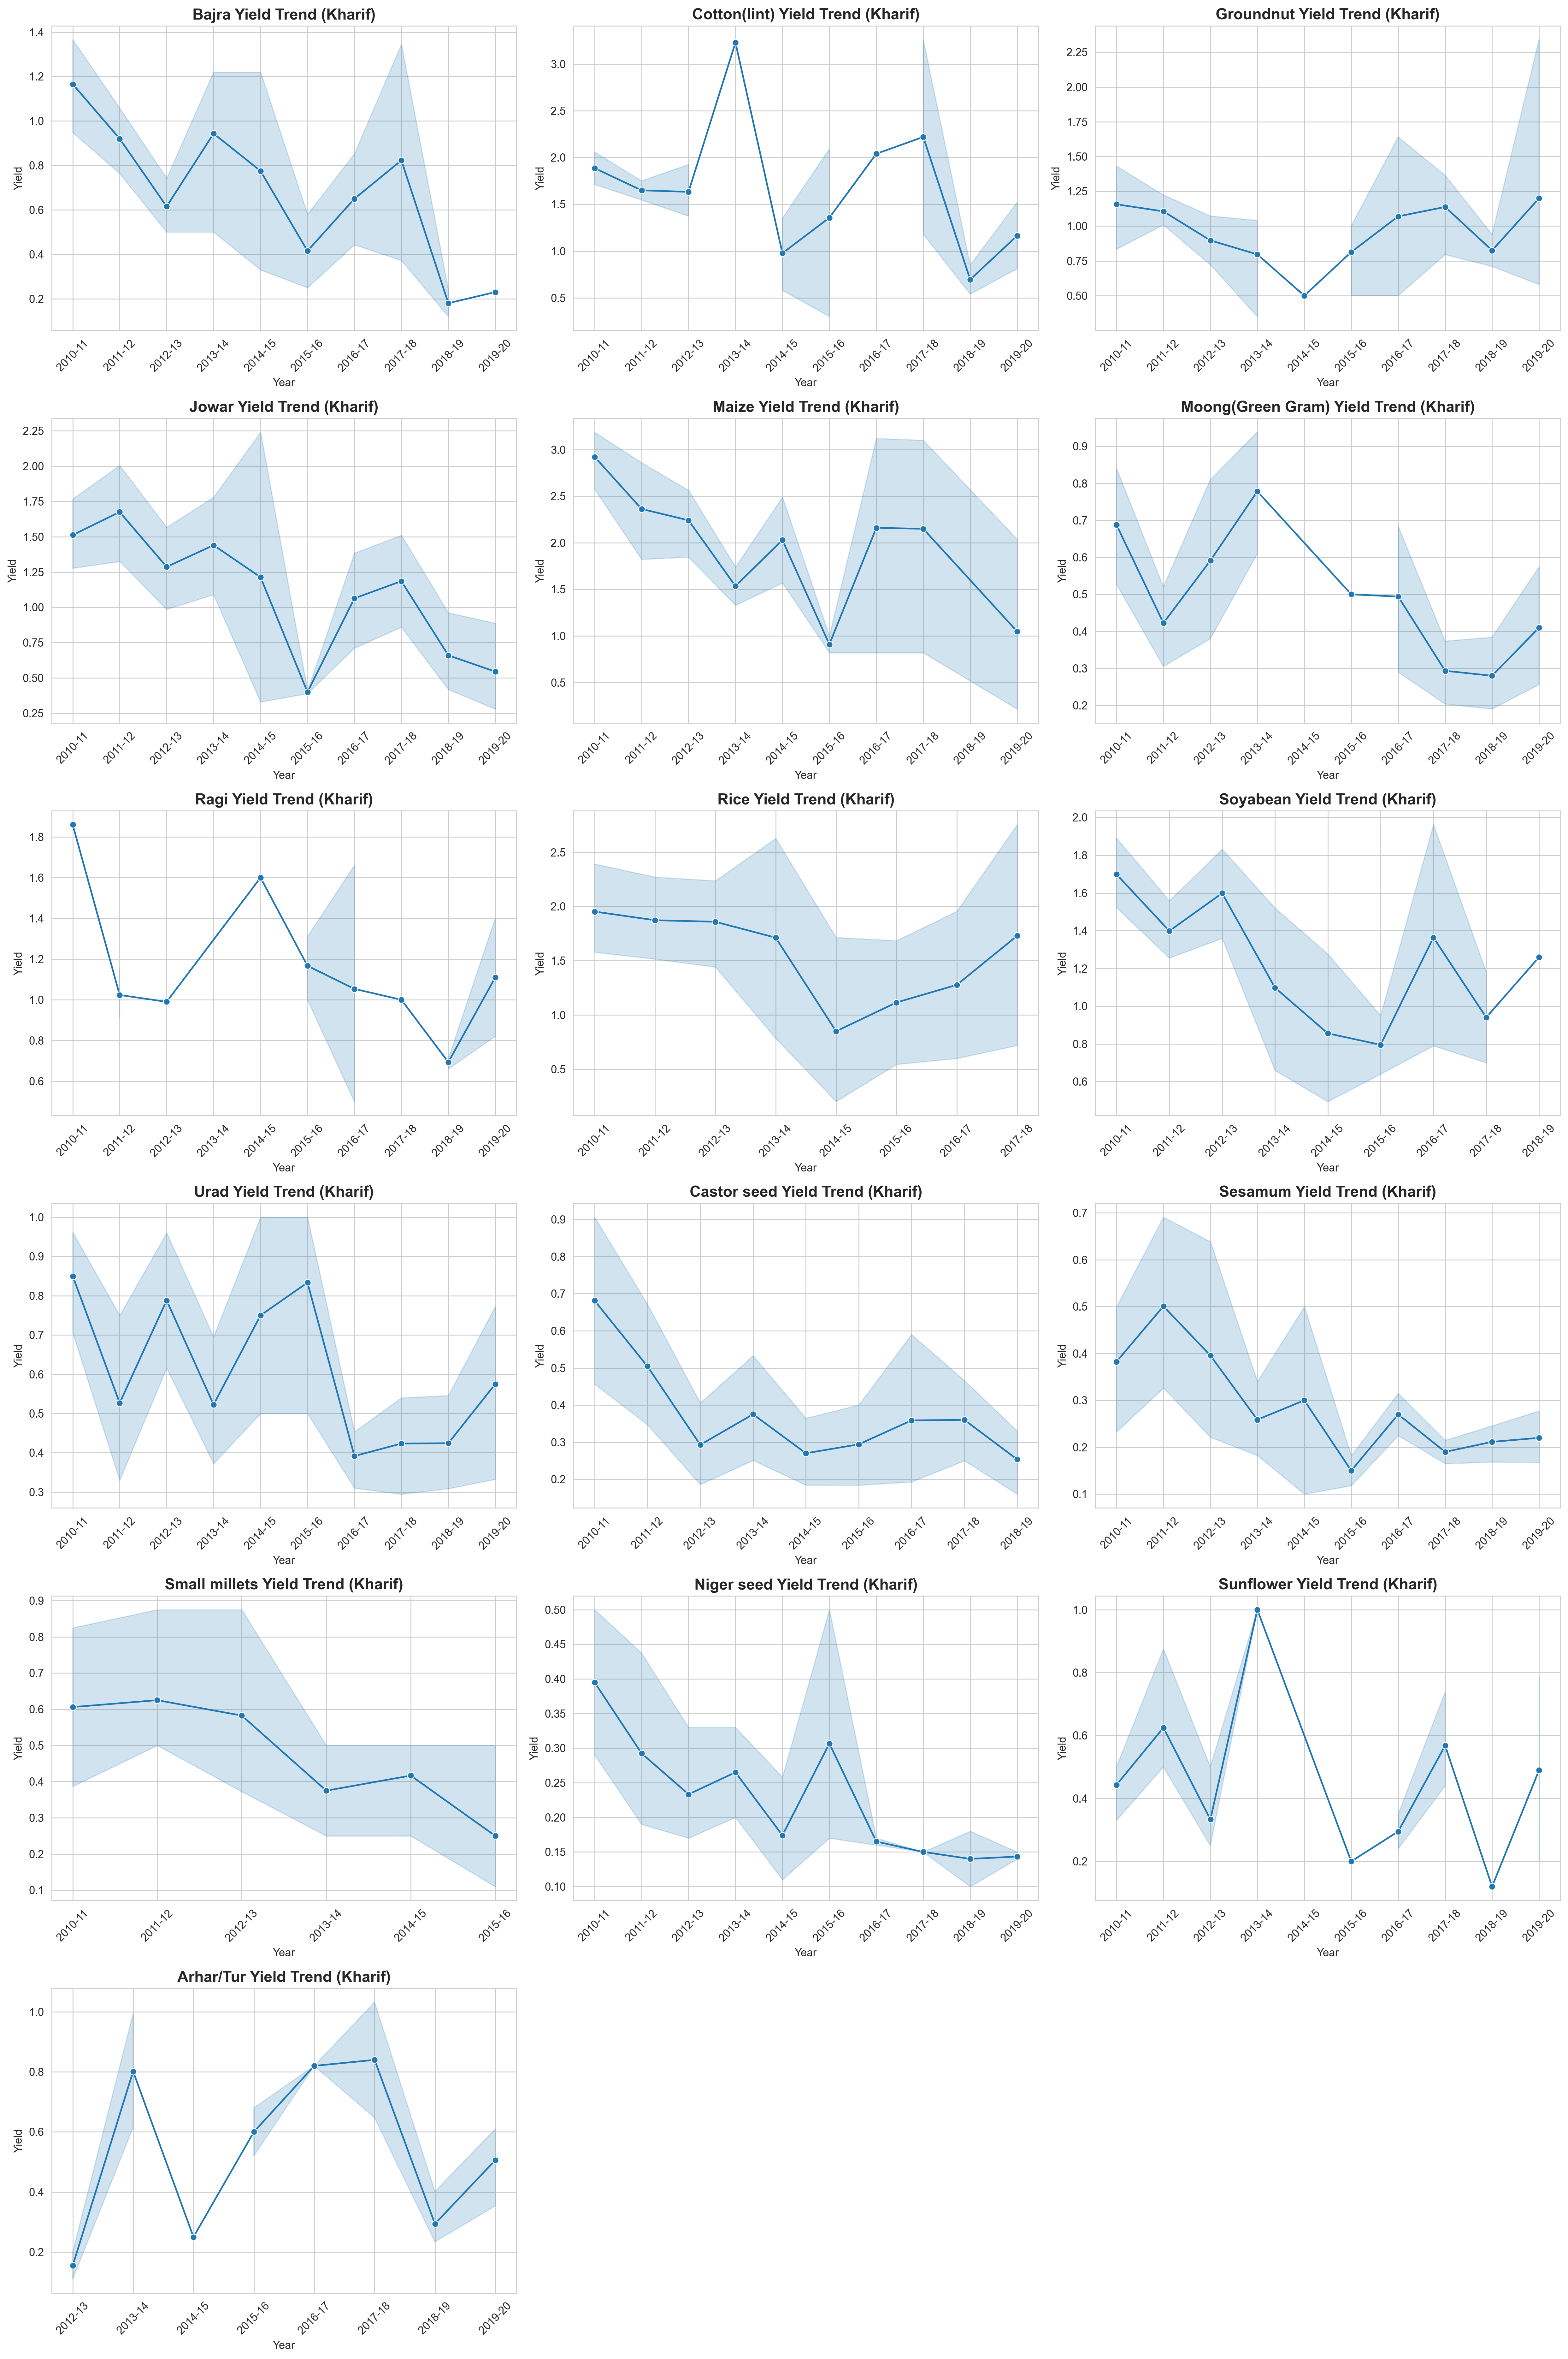

In [33]:
# --------------------------
# KHARIF SEASON VISUALIZATION
# --------------------------

# Filter only Kharif season data
kharif_data = df[df['Season'] == 'Kharif'].copy()

# Get all unique crop names grown in Kharif
unique_kharif_crops = kharif_data['Crop'].unique()

# Define the desired order of years
year_order = sorted(kharif_data['Year'].unique())

# Convert 'Year' to a categorical type with ordered categories
kharif_data['Year'] = pd.Categorical(kharif_data['Year'], categories=year_order, ordered=True)


# Count number of unique crops
num_crops = len(unique_kharif_crops)

# Define subplot grid (3 columns, rows calculated automatically)
num_cols = 3
num_rows = (num_crops + num_cols - 1) // num_cols

# Set seaborn style for consistency
sns.set_style("whitegrid")
sns.set_palette("tab10")

# Create subplot grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))

# Flatten axes array to loop easily
axes = axes.flatten()

# Plot each crop’s yield trend
for i, crop in enumerate(unique_kharif_crops):
    # Filter data for this crop
    crop_data = kharif_data[kharif_data['Crop'] == crop]

    # Plot line graph (Year vs Yield)
    sns.lineplot(data=crop_data, x='Year', y='Yield(ton/ha)', ax=axes[i], marker='o')

    # Add title and labels
    axes[i].set_title(f'{crop} Yield Trend (Kharif)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Yield')

    # Rotate x-axis ticks
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Show figure
plt.show()

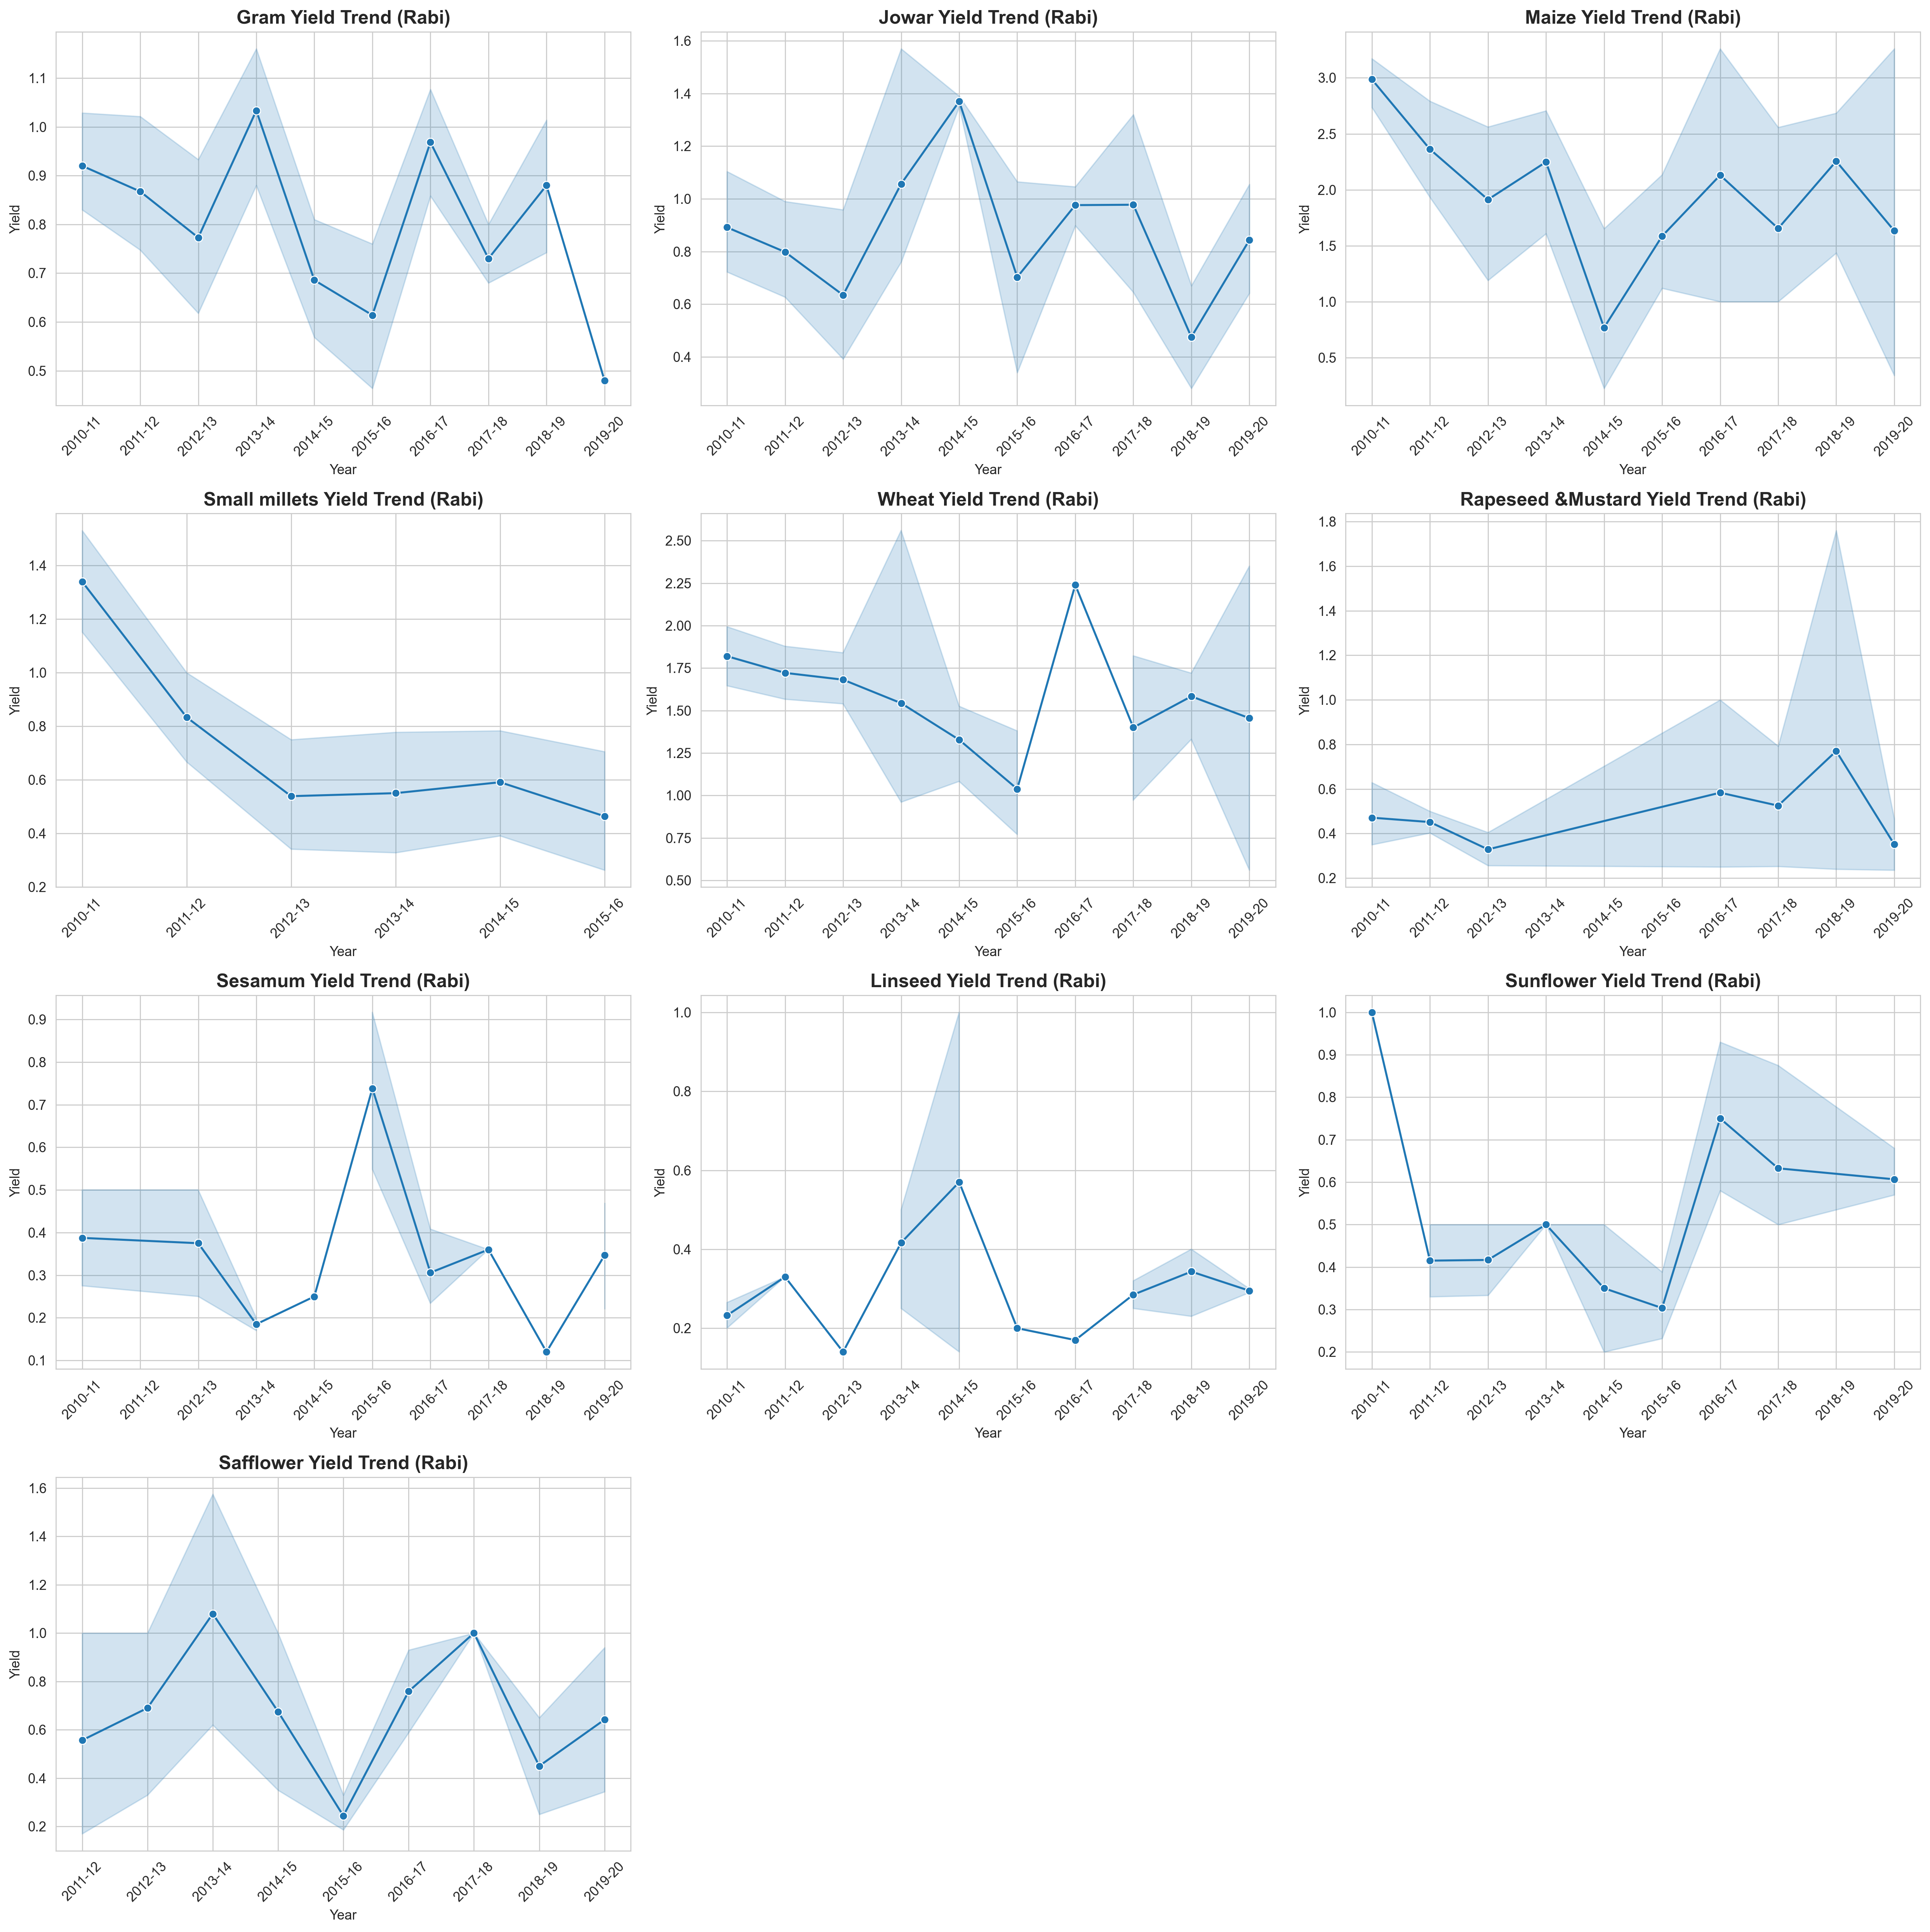

In [34]:
# --------------------------
# RABI SEASON VISUALIZATION
# --------------------------

# Filter only rabi season data
rabi_data = df[df['Season'] == 'Rabi'].copy()

# Get all unique crop names grown in rabi
unique_rabi_crops = rabi_data['Crop'].unique()

# Define the desired order of years
year_order = sorted(rabi_data['Year'].unique())

# Convert 'Year' to a categorical type with ordered categories
rabi_data['Year'] = pd.Categorical(rabi_data['Year'], categories=year_order, ordered=True)

# Count number of unique crops
num_crops = len(unique_rabi_crops)

# Define number of columns in subplot grid
num_cols = 3

# Calculate required number of rows to fit all crops
num_rows = (num_crops + num_cols - 1) // num_cols

# Create subplot grid (rows x cols) with large figure size
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))

# Flatten axes array to easily loop through
axes = axes.flatten()

# Loop through each crop and plot yield trends
for i, crop in enumerate(unique_rabi_crops):
    # Filter data for the specific crop
    crop_data = rabi_data[rabi_data['Crop'] == crop]

    # Plot line graph with markers (Year vs Yield)
    sns.lineplot(data=crop_data, x='Year', y='Yield(ton/ha)', ax=axes[i], marker='o')

    # Set title for each subplot
    axes[i].set_title(f'{crop} Yield Trend (Rabi)', fontsize=14, fontweight='bold')

    # Label X and Y axes
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Yield')

    # Rotate x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra unused subplots (if grid has more cells than crops)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout so titles/labels don’t overlap
plt.tight_layout()

# Display the figure
plt.show()

In [35]:
# ==============================
# District-Wise Crop Production
# ==============================
# Unique districts
districts = df['District'].unique()
n_districts = len(districts)

import math
# Define subplot grid
cols = 3
rows = math.ceil(n_districts / cols)


fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()


# Loop through each district and plot crops vs production
for i, district in enumerate(districts):
  district_data = df[df['District'] == district]
  sns.barplot(x='Crop', y='Production(tons)', data=district_data, ci=None, ax=axes[i])
  axes[i].set_title(f"{district}", fontsize=14)
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
  axes[i].set_ylabel("Total Production")
  axes[i].set_xlabel("Crop")


# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.savefig("District-Wise Crop plot.jpg")
plt.show()

In [36]:
# Feature selection and preprocessing
target = 'Yield(ton/ha)'
features = filtered_data.drop(columns=[target])

In [37]:
print(features)

        District   Crop     Year  Season  Area(Ha)  Production(tons)
0     AURANGABAD  Bajra  2010-11  Kharif   89800.0          126500.0
1           BEED  Bajra  2010-11  Kharif  122500.0          112800.0
2          DHULE  Bajra  2010-11  Kharif  109400.0          171300.0
3        JALGAON  Bajra  2010-11  Kharif   35800.0           49800.0
4         NASHIK  Bajra  2010-11  Kharif  137300.0          210350.0
...          ...    ...      ...     ...       ...               ...
1297    BULDHANA   Urad  2019-20  Kharif   16580.0           11031.0
1298    KOLHAPUR   Urad  2019-20  Kharif    1871.0            1564.0
1299       LATUR   Urad  2019-20  Kharif    7538.0            4287.0
1300      GONDIA  Wheat  2019-20    Rabi    3032.0            1690.0
1301    KOLHAPUR  Wheat  2019-20    Rabi    3398.0            8001.0

[1302 rows x 6 columns]


In [38]:
# Separate categorical and numerical columns
categorical_columns = features.select_dtypes(include=['object']).columns
numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns

In [39]:
# Encode categorical data
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_encoded = encoder.fit_transform(features[categorical_columns]).toarray()
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

In [40]:
# Scale numerical data
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(features[numerical_columns])

In [41]:
# Combine processed features
X_processed = np.hstack((numerical_scaled, categorical_encoded))
feature_names = list(numerical_columns) + list(categorical_feature_names)

In [42]:
# Split the data into training and testing sets
X = X_processed
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42)
}
model_list = []
r2_list =[]

In [45]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3731
- Mean Absolute Error: 0.2759
- R2 Score: 0.8272
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3930
- Mean Absolute Error: 0.2856
- R2 Score: 0.7987


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2770
- Mean Absolute Error: 0.1821
- R2 Score: 0.9047
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3566
- Mean Absolute Error: 0.2417
- R2 Score: 0.8342


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2547
- Mean Absolute Error: 0.1165
- R2 Score: 0.9154


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.0750
- Mean Absolute Error: 0.0357
- R2 Score: 0.99

In [46]:
# Find the best model based on R2 score
best_model_index = r2_list.index(max(r2_list))
best_model_name = model_list[best_model_index]
best_model = list(models.values())[best_model_index]

print(f"Best Model: {best_model_name}")

# Use the best model to make predictions on the test set
y_pred_best_model = best_model.predict(X_test)

# Evaluate the best model
mae_best, rmse_best, r2_best = evaluate_model(y_test, y_pred_best_model)

print('\nModel performance for Test set (Best Model)')
print("- Root Mean Squared Error: {:.4f}".format(rmse_best))
print("- Mean Absolute Error: {:.4f}".format(mae_best))
print("- R2 Score: {:.4f}".format(r2_best))

Best Model: Random Forest Regressor

Model performance for Test set (Best Model)
- Root Mean Squared Error: 0.1850
- Mean Absolute Error: 0.0878
- R2 Score: 0.9554


In [47]:
score = r2_best*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 95.54


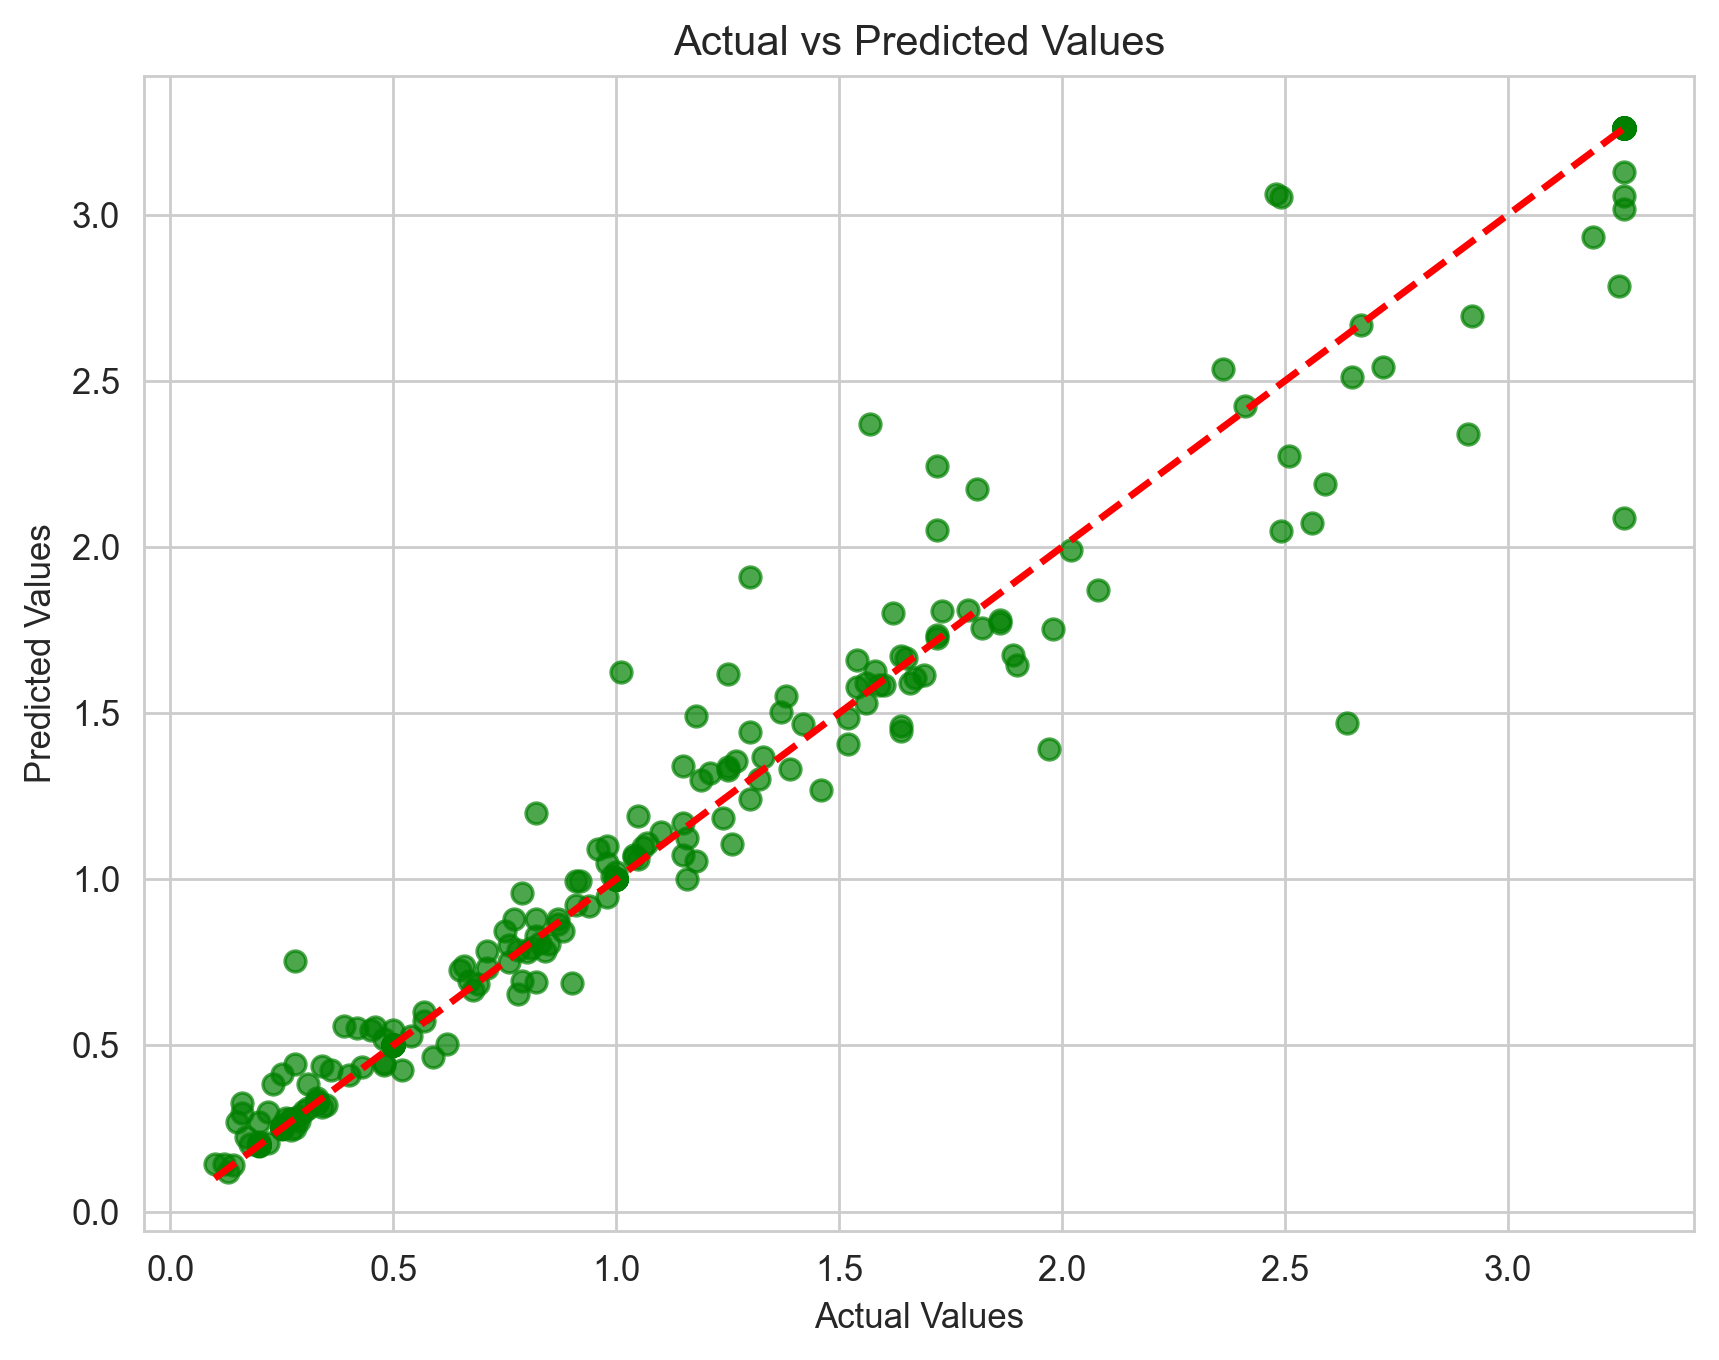

In [48]:
# Visualization of predictions vs actual values for the last model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_model, alpha=0.7, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.savefig("Final-Plot.jpg")
plt.show()

In [49]:
pred_values=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred_best_model})
pred_values

,Actual Value,Predicted Value
478,2.51,2.2731
724,1.00,1.0000
312,3.19,2.9343
851,1.21,1.3199
1275,1.15,1.0729
...,...,...
199,0.20,0.2000
296,1.05,1.1898
286,1.25,1.3300
997,0.50,0.5015
